# 7장 시각화 라이브러리

## 7.3 시본(Seaborn) 라이브러리

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_excel('health_screenings_2020_1000ea.xlsx')
data.head()

,year,city_code,gender,age_code,height,weight,waist,eye_left,eye_right,hear_left,...,serum,AST,ALT,GTP,smoking,drinking,oral_check,dental_caries,tartar,open_date
0,2020,36,1,9,165,60,72.1,1.2,1.5,1,...,1.1,21.0,27.0,21.0,1,0,0,NaN,NaN,2021-12-29
1,2020,27,2,13,150,65,81.0,0.8,0.8,1,...,0.5,18.0,15.0,15.0,1,0,0,NaN,NaN,2021-12-29
2,2020,11,2,12,155,55,70.0,0.6,0.7,1,...,0.7,27.0,25.0,7.0,1,0,0,NaN,NaN,2021-12-29
3,2020,31,1,13,160,70,90.8,1.0,1.0,1,...,1.2,65.0,97.0,72.0,1,0,1,0.0,0.0,2021-12-29
4,2020,41,2,12,155,50,75.2,1.5,1.2,1,...,0.7,18.0,17.0,14.0,1,0,0,NaN,NaN,2021-12-29


In [14]:
data6 = data.loc[:,['gender', 'height', 'weight', 'waist', 'drinking', 'smoking']]
data6

,gender,height,weight,waist,drinking,smoking
0,1,165,60,72.1,0,1
1,2,150,65,81.0,0,1
2,2,155,55,70.0,0,1
3,1,160,70,90.8,0,1
4,2,155,50,75.2,0,1
...,...,...,...,...,...,...
995,1,165,70,92.0,1,3
996,1,165,70,88.0,0,2
997,2,155,55,80.2,1,1
998,2,150,55,79.5,0,1


In [16]:
data6.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   gender    1000 non-null   int64  
 1   height    1000 non-null   int64  
 2   weight    1000 non-null   int64  
 3   waist     1000 non-null   float64
 4   drinking  1000 non-null   int64  
 5   smoking   1000 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 47.0 KB


In [17]:
data6['gender'].map({1:'Male', 2:'Female'})

0        Male
1      Female
2      Female
3        Male
4      Female
        ...  
995      Male
996      Male
997    Female
998    Female
999      Male
Name: gender, Length: 1000, dtype: str

In [18]:
data6['gender'] = data6['gender'].map({1:'Male', 2:'Female'})

data6

,gender,height,weight,waist,drinking,smoking
0,Male,165,60,72.1,0,1
1,Female,150,65,81.0,0,1
2,Female,155,55,70.0,0,1
3,Male,160,70,90.8,0,1
4,Female,155,50,75.2,0,1
...,...,...,...,...,...,...
995,Male,165,70,92.0,1,3
996,Male,165,70,88.0,0,2
997,Female,155,55,80.2,1,1
998,Female,150,55,79.5,0,1


In [19]:
data6['drinking'].map({0: 'Non-drinking', 1: 'Drinking'})

0      Non-drinking
1      Non-drinking
2      Non-drinking
3      Non-drinking
4      Non-drinking
           ...     
995        Drinking
996    Non-drinking
997        Drinking
998    Non-drinking
999        Drinking
Name: drinking, Length: 1000, dtype: str

In [20]:
data6['drinking'] = data6['drinking'].map({0: 'Non-drinking', 1: 'Drinking'})

In [21]:
data6['smoking'].map({1: 'Non-smoking', 2: 'Non-smoking', 3: 'Smoking'})

0      Non-smoking
1      Non-smoking
2      Non-smoking
3      Non-smoking
4      Non-smoking
          ...     
995        Smoking
996    Non-smoking
997    Non-smoking
998    Non-smoking
999    Non-smoking
Name: smoking, Length: 1000, dtype: str

In [22]:
data6['smoking'] = data6['smoking'].map({1: 'Non-smoking', 2: 'Non-smoking', 3: 'Smoking'})

In [23]:
# ✅ Cell 2: map으로 치환


data6

,gender,height,weight,waist,drinking,smoking
0,Male,165,60,72.1,Non-drinking,Non-smoking
1,Female,150,65,81.0,Non-drinking,Non-smoking
2,Female,155,55,70.0,Non-drinking,Non-smoking
3,Male,160,70,90.8,Non-drinking,Non-smoking
4,Female,155,50,75.2,Non-drinking,Non-smoking
...,...,...,...,...,...,...
995,Male,165,70,92.0,Drinking,Smoking
996,Male,165,70,88.0,Non-drinking,Non-smoking
997,Female,155,55,80.2,Drinking,Non-smoking
998,Female,150,55,79.5,Non-drinking,Non-smoking


In [24]:
drinking = data6.groupby(['gender', 'drinking'])['drinking'].count()
smoking = data6.groupby(['gender', 'smoking'])['smoking'].count()
drinking = drinking.to_frame(name='count')
smoking = smoking.to_frame(name='count')
drinking = drinking.reset_index()
smoking = smoking.reset_index()

In [25]:
drinking

,gender,drinking,count
0,Female,Drinking,213
1,Female,Non-drinking,305
2,Male,Drinking,356
3,Male,Non-drinking,126


In [26]:
smoking

,gender,smoking,count
0,Female,Non-smoking,500
1,Female,Smoking,18
2,Male,Non-smoking,321
3,Male,Smoking,161


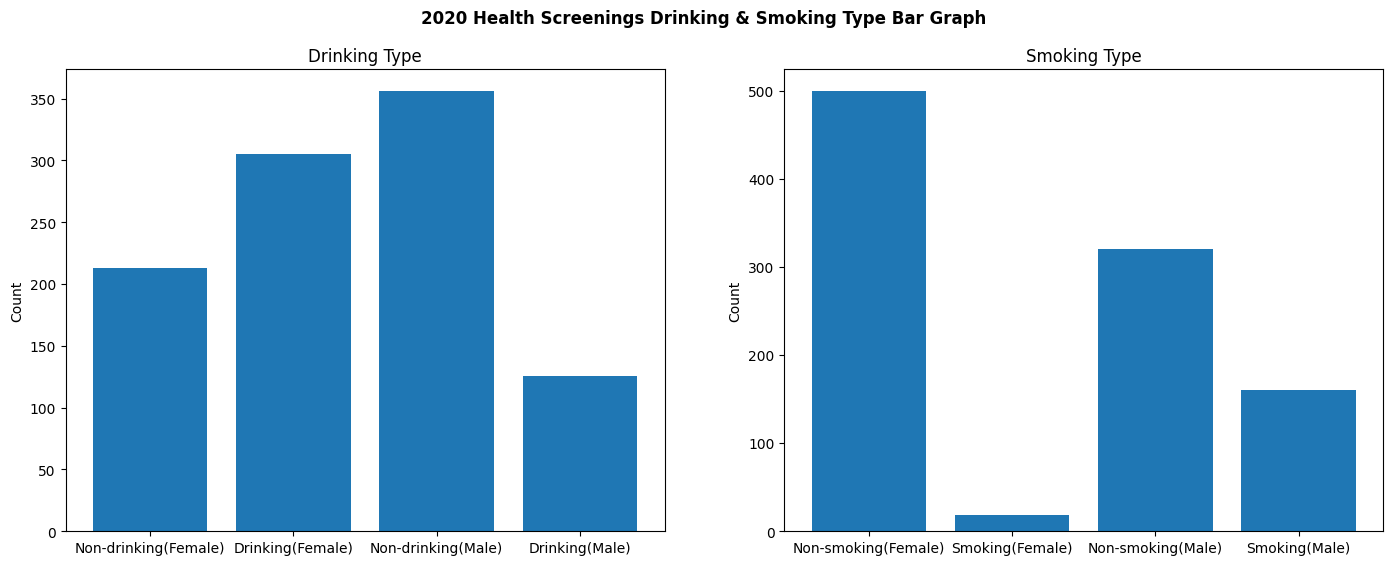

In [27]:
fig = plt.figure(figsize=(17,6))
fig.suptitle('2020 Health Screenings Drinking & Smoking Type Bar Graph',fontweight='bold')
index = np.arange(4)

fig.add_subplot(1,2,1)

plt.bar(index, drinking['count'])
plt.title('Drinking Type')
plt.ylabel('Count')
plt.xticks(index, ['Non-drinking(Female)','Drinking(Female)','Non-drinking(Male)','Drinking(Male)'])

fig.add_subplot(1,2,2)

plt.bar(index, smoking['count'])
plt.title('Smoking Type')
plt.ylabel('Count')
plt.xticks(index, ['Non-smoking(Female)', 'Smoking(Female)', 'Non-smoking(Male)', 'Smoking(Male)'])

plt.show()

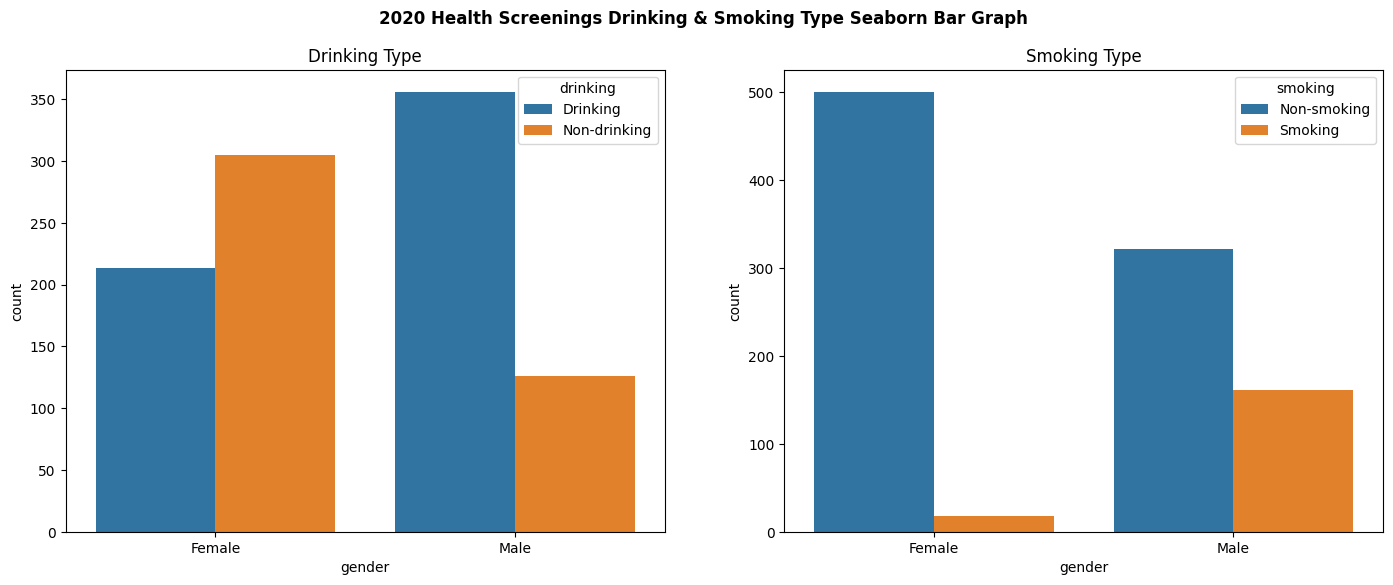

In [28]:
fig = plt.figure(figsize=(17,6))

area1 = fig.add_subplot(1,2,1)
area2 = fig.add_subplot(1,2,2)

ax1 = sns.barplot(data=drinking,x='gender',y='count',hue='drinking',ax=area1)
ax2 = sns.barplot(data=smoking,x='gender',y='count',hue='smoking',ax=area2)

fig.suptitle('2020 Health Screenings Drinking & Smoking Type Seaborn Bar Graph',fontweight='bold')
area1.set_title('Drinking Type')
area2.set_title('Smoking Type')

plt.show()

In [29]:
male_data = data6.loc[data6.gender=='Male',['gender','weight','waist','drinking','smoking']]
female_data = data6.loc[data6.gender=='Female',['gender','weight','waist','drinking','smoking']]

In [30]:
min(female_data['waist'])

53.0

In [31]:
max(male_data['waist'])

128.0

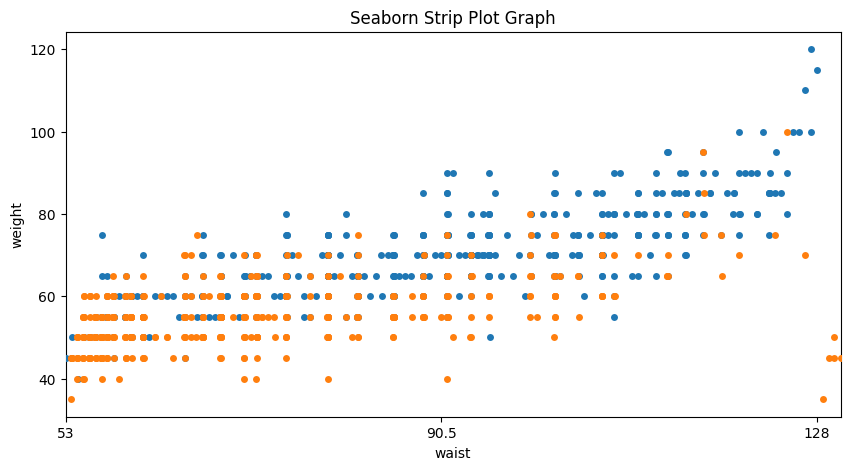

In [41]:
plt.figure(figsize=(10,5))
plt.title('Seaborn Strip Plot Graph')

sns.stripplot(data=male_data, x='waist', y='weight')
sns.stripplot(data=female_data, x='waist', y='weight' )
# sns.stripplot(data=data6, x='waist', y='weight', hue='gender')

plt.xlim(0, 130)
plt.xticks(np.arange(0,129,63), labels=[53, 90.5, 128])
plt.show()

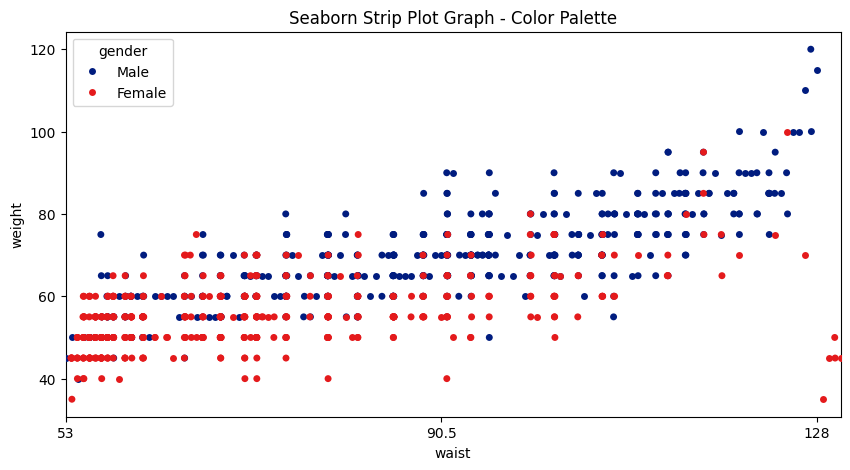

In [42]:
plt.figure(figsize=(10,5))
plt.title('Seaborn Strip Plot Graph - Color Palette')

sns.stripplot(data=male_data, x='waist', y='weight', hue='gender', palette='dark')
sns.stripplot(data=female_data, x='waist', y='weight', hue='gender', palette='Set1')
plt.xlim(0, 130)
plt.xticks(np.arange(0,127,63), labels=[53, 90.5, 128])
plt.show()

In [36]:
male_data_100 = male_data.head(100)
female_data_100 = female_data.head(100)

c:\Users\seoks\ai_class\streamlit_labs_3333\.venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\seoks\ai_class\streamlit_labs_3333\.venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 33.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\seoks\ai_class\streamlit_labs_3333\.venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 50.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\seoks\ai_class\streamlit_labs_3333\.venv\Lib\site-packages\seaborn\categorical.py:3399: UserWarning: 40.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\U

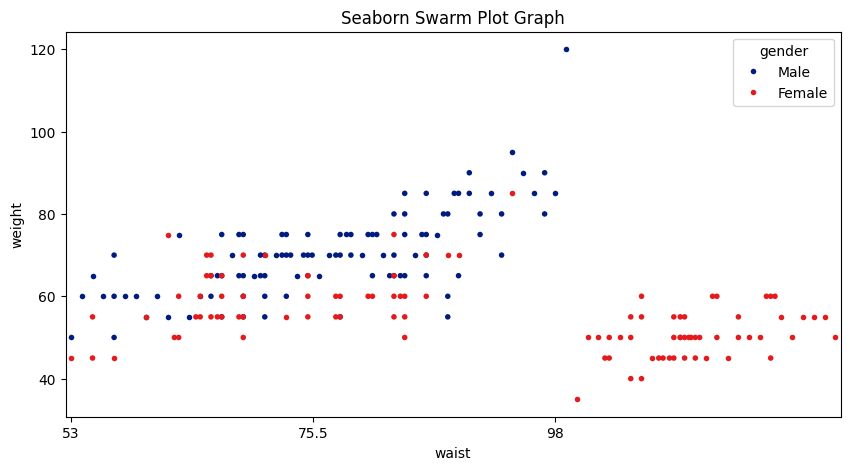

In [44]:
plt.figure(figsize=(10,5))
plt.title('Seaborn Swarm Plot Graph')

sns.swarmplot(data=male_data_100,x='waist',y='weight',hue='gender',palette='dark',size=4)
sns.swarmplot(data=female_data_100,x='waist',y='weight',hue='gender',palette='Set1',size=4)

plt.xticks(np.arange(0,46,22.5), labels=[53, 75.5, 98])
plt.show()

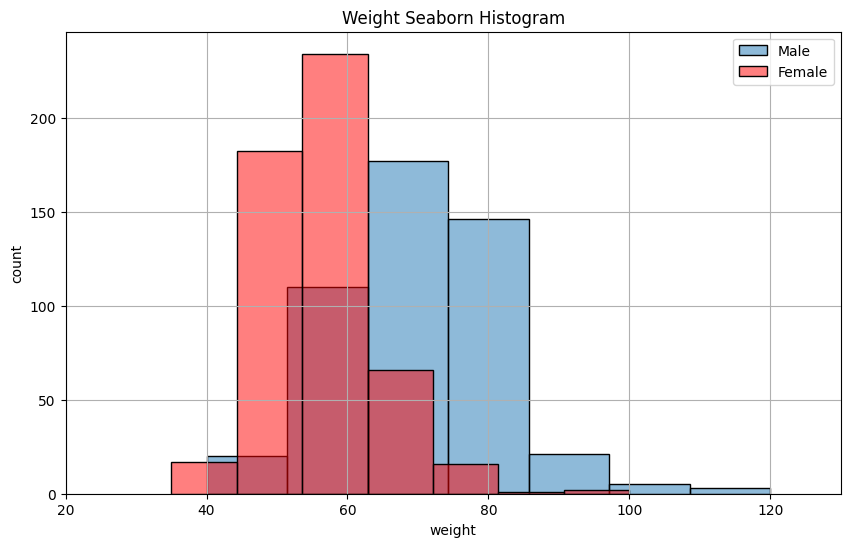

In [45]:
plt.figure(figsize=(10,6))
sns.histplot(male_data['weight'], bins=7, alpha=0.5, label='Male')
sns.histplot(female_data['weight'], bins=7, alpha=0.5, label='Female', color='r')

plt.xlim(20,130)
plt.xlabel('weight')
plt.ylabel('count')
plt.title('Weight Seaborn Histogram')
plt.legend()
plt.grid()
plt.show()

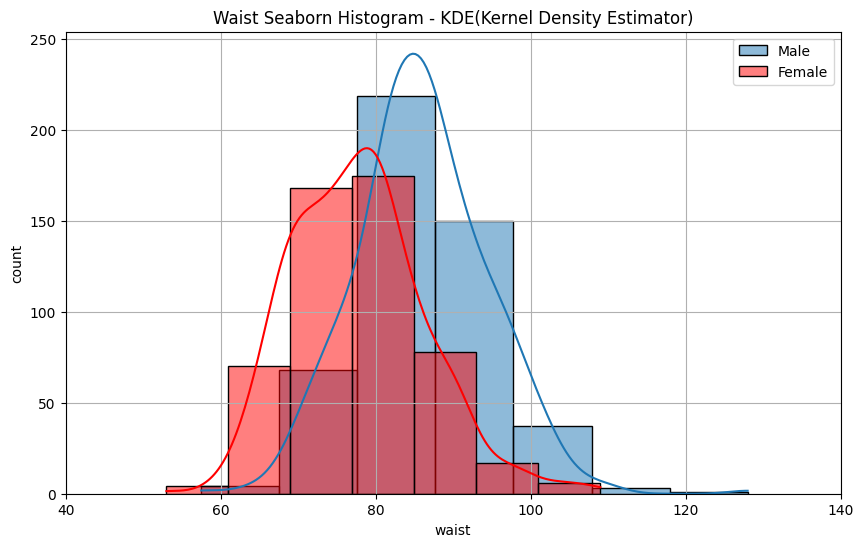

In [46]:
plt.figure(figsize=(10,6))
sns.histplot(male_data['waist'], bins=7, alpha=0.5, label='Male', kde=True)
sns.histplot(female_data['waist'], bins=7, alpha=0.5, label='Female', color='r', kde=True)

plt.xlim(40,140)
plt.xlabel('waist')
plt.ylabel('count')
plt.title('Waist Seaborn Histogram - KDE(Kernel Density Estimator)')
plt.legend()
plt.grid()
plt.show()

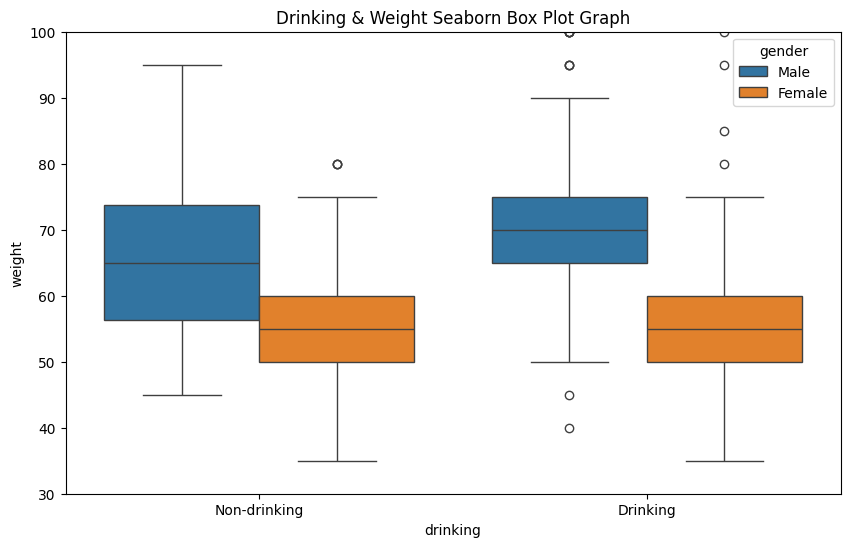

In [47]:
plt.figure(figsize=(10,6))
plt.title('Drinking & Weight Seaborn Box Plot Graph')

sns.boxplot(data=data6, x='drinking', y='weight', hue='gender')
plt.ylim(30,100)
plt.show()

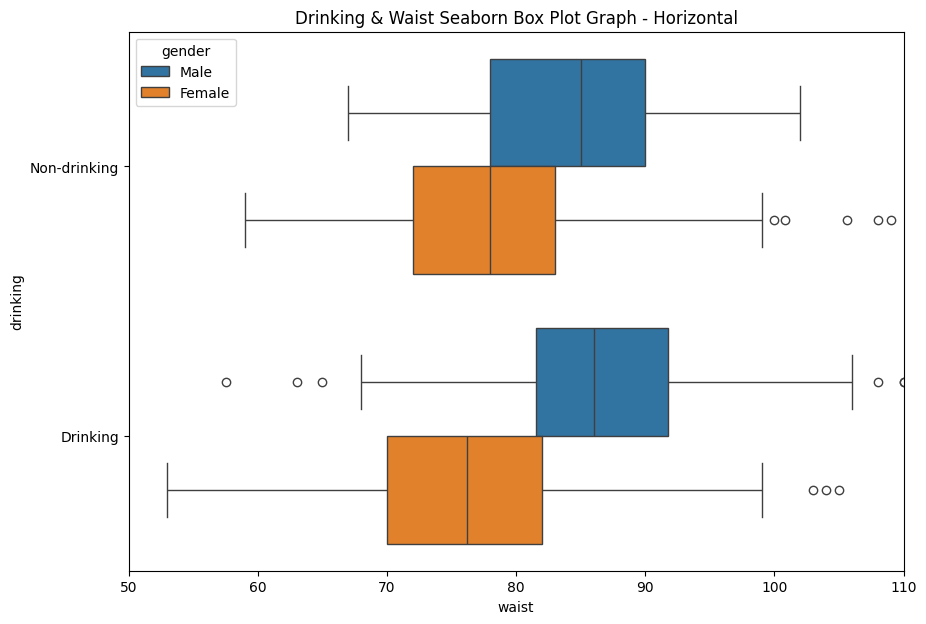

In [48]:
plt.figure(figsize=(10,7))
plt.title('Drinking & Waist Seaborn Box Plot Graph - Horizontal')

sns.boxplot(data=data6, x='waist', y='drinking', hue='gender', orient='h')
plt.xlim(50,110)
plt.show()

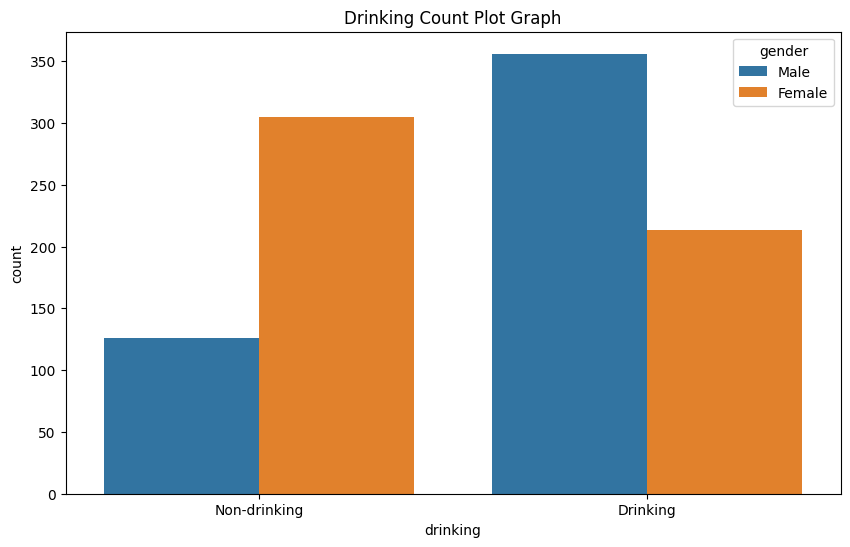

In [49]:
plt.figure(figsize=(10,6))
plt.title('Drinking Count Plot Graph')
sns.countplot(data=data6, x='drinking', hue='gender')
plt.show()

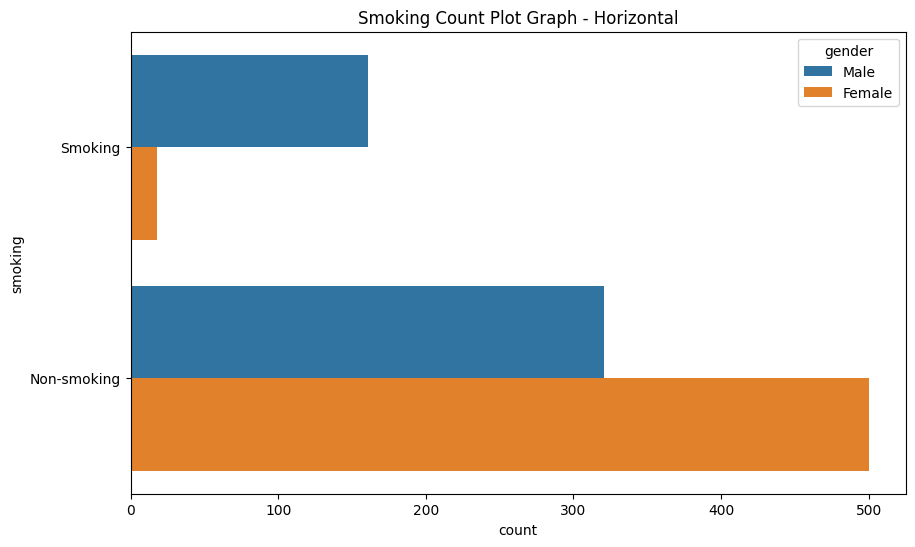

In [50]:
plt.figure(figsize=(10,6))
plt.title('Smoking Count Plot Graph - Horizontal')
sns.countplot(data=data6, y='smoking', hue='gender', order=['Smoking','Non-smoking'])
plt.show()

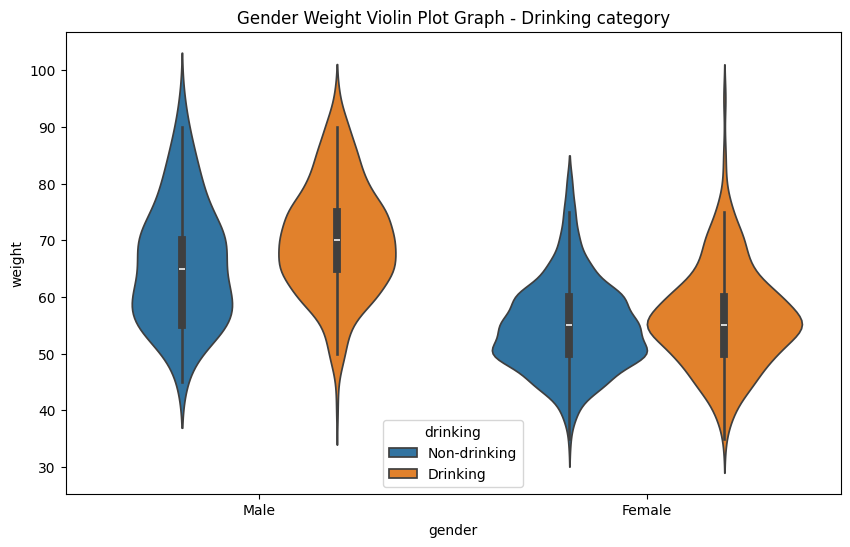

In [51]:
plt.figure(figsize=(10,6))
plt.title('Gender Weight Violin Plot Graph - Drinking category')
sns.violinplot(data=data6[data6.weight<100], x='gender', y='weight', hue='drinking')
plt.show()

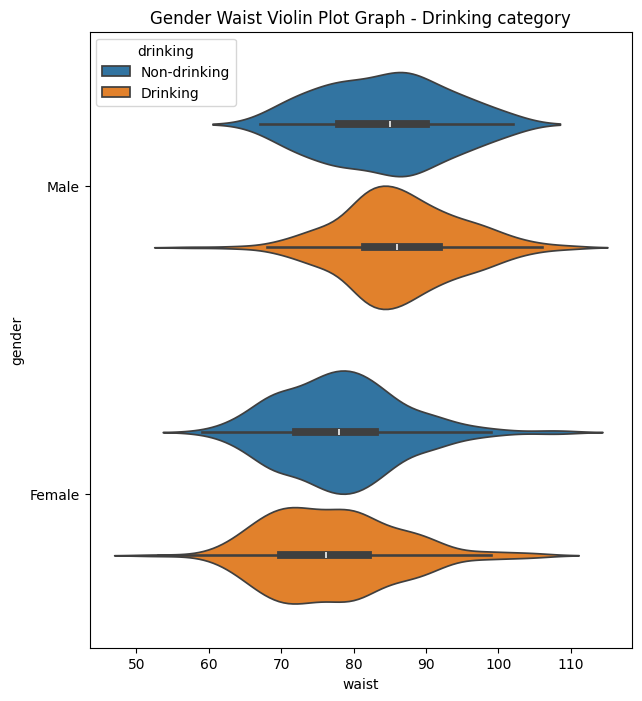

In [52]:
plt.figure(figsize=(7,8))
plt.title('Gender Waist Violin Plot Graph - Drinking category')
sns.violinplot(data=data6[data6.waist<120], y='gender', x='waist', hue='drinking')
plt.show()

In [53]:
data3 = data.loc[:,['gender','weight','waist']]
data8 = data.loc[:,['gender','weight','waist','drinking','smoking','cholesterol','HDL','LDL']]

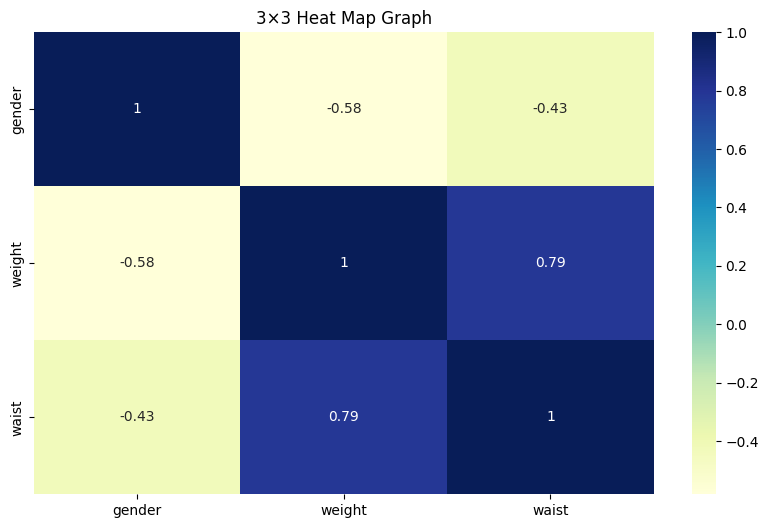

In [54]:
plt.figure(figsize=(10,6))
plt.title('3×3 Heat Map Graph')

correlation_data3 = data3.corr()
sns.heatmap(correlation_data3, annot=True, cmap='YlGnBu')
plt.show()

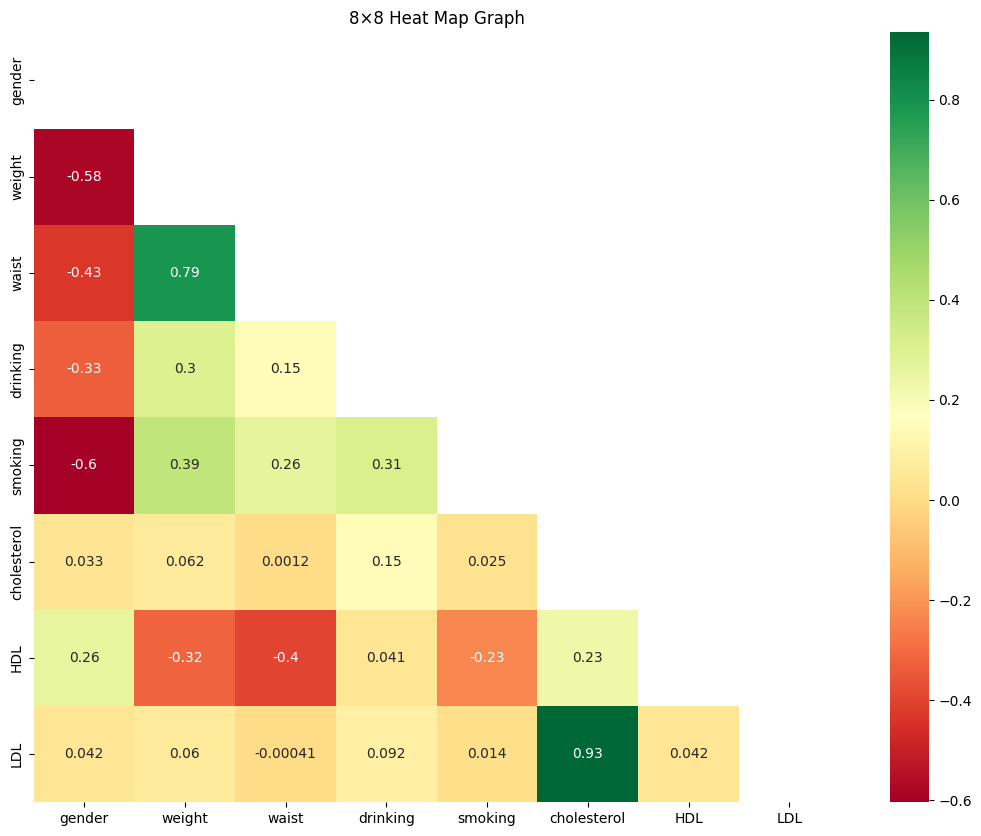

In [55]:
plt.figure(figsize=(13,10))
plt.title('8×8 Heat Map Graph')

correlation_data8= data8.corr()
upp_mat = np.triu(correlation_data8)

sns.heatmap(correlation_data8, annot=True, cmap='RdYlGn', mask=upp_mat)
plt.show()

In [56]:
data12 = data.loc[:,['gender','weight','waist','drinking','smoking','AST','ALT','systolic','diastolic','cholesterol','HDL','LDL']]

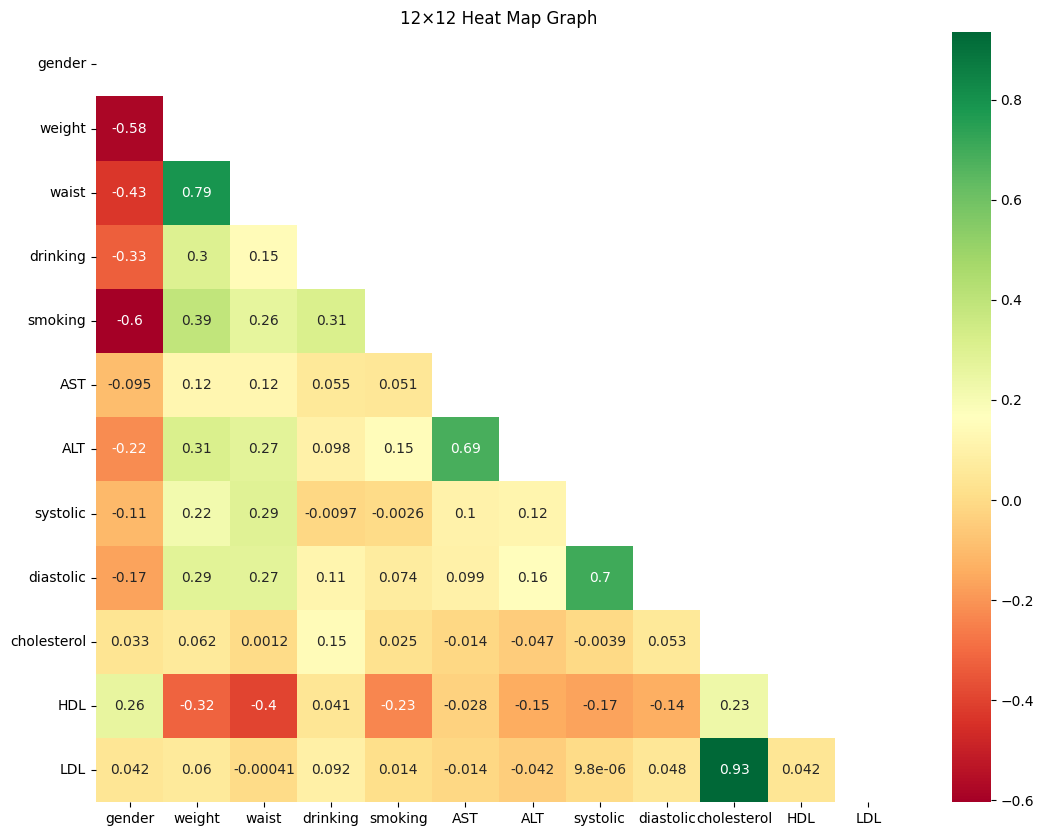

In [57]:
plt.figure(figsize=(13,10))
plt.title('12×12 Heat Map Graph')

correlation_data12= data12.corr()
upp_mat = np.triu(correlation_data12)

sns.heatmap(correlation_data12, annot=True, cmap='RdYlGn', mask=upp_mat)
plt.show()

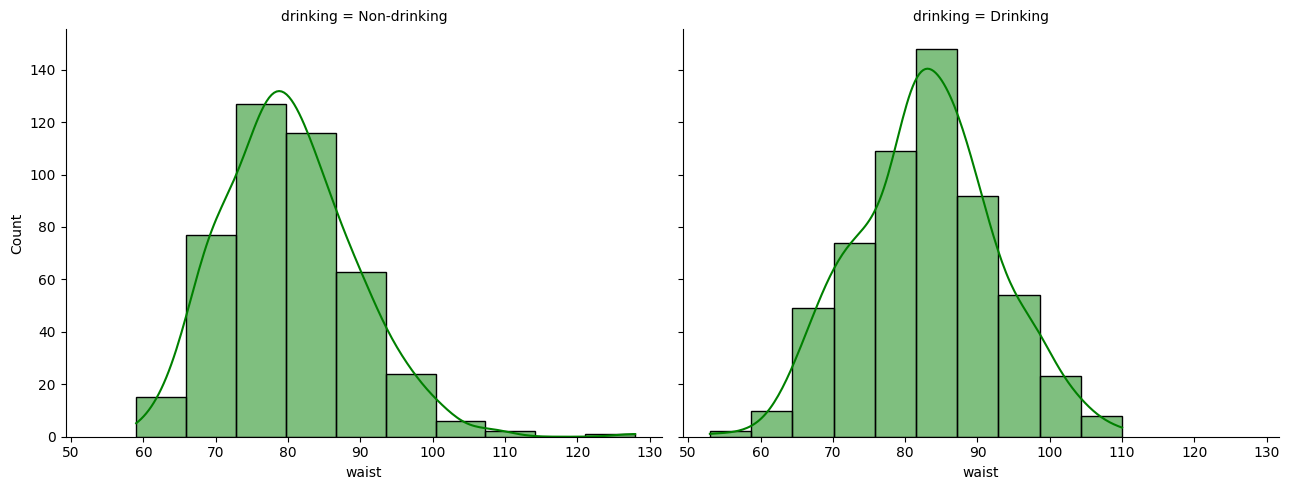

In [58]:
fg = sns.FacetGrid(data6, col='drinking', height=5, aspect=1.3)
fg.map(sns.histplot, 'waist', bins=10, color='g', kde=True)
plt.show()

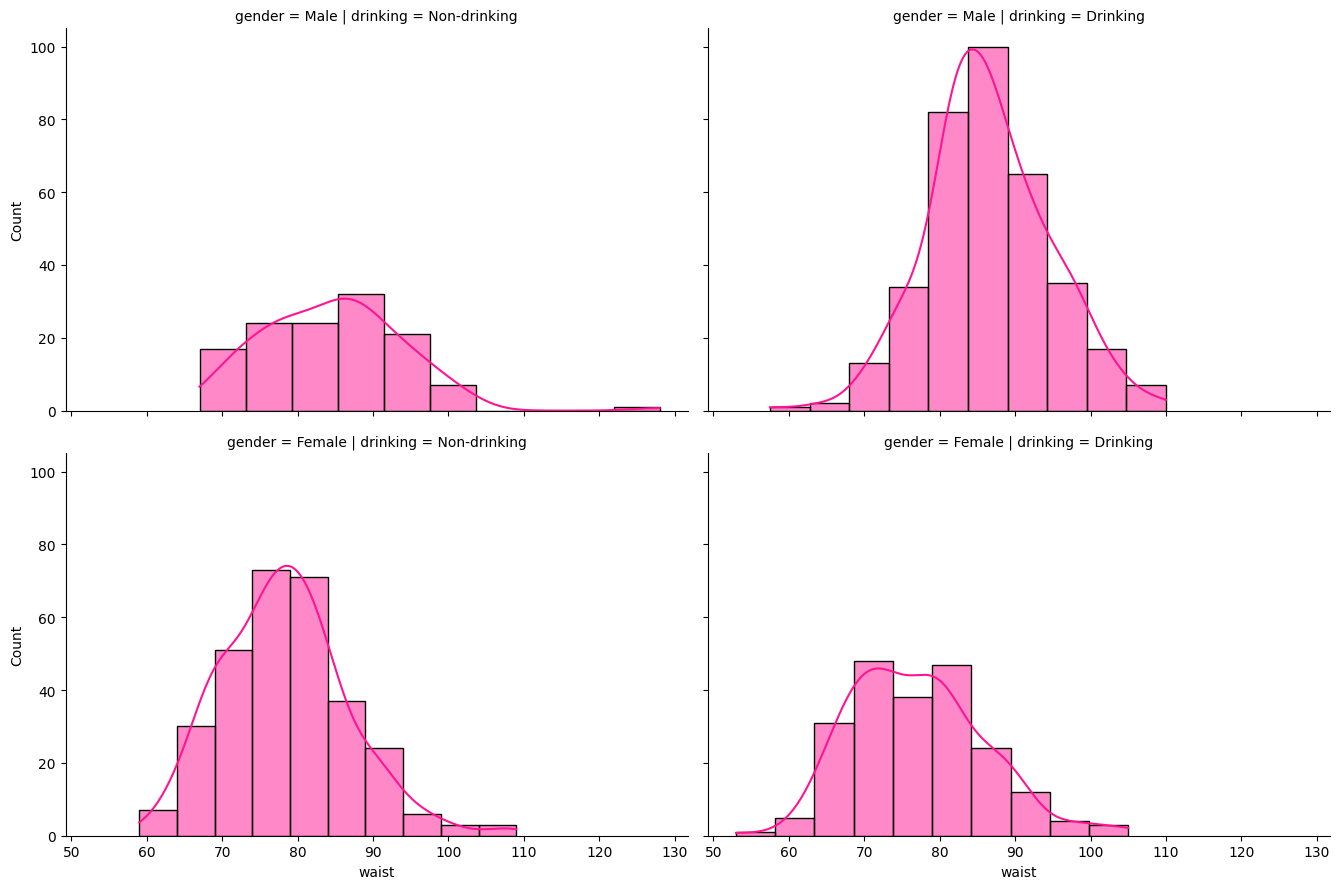

In [59]:
fg = sns.FacetGrid(data6, row='gender', col='drinking', height=4.5, aspect=1.5)
fg.map(sns.histplot, 'waist', bins=10, color='deeppink', kde=True)
plt.show()

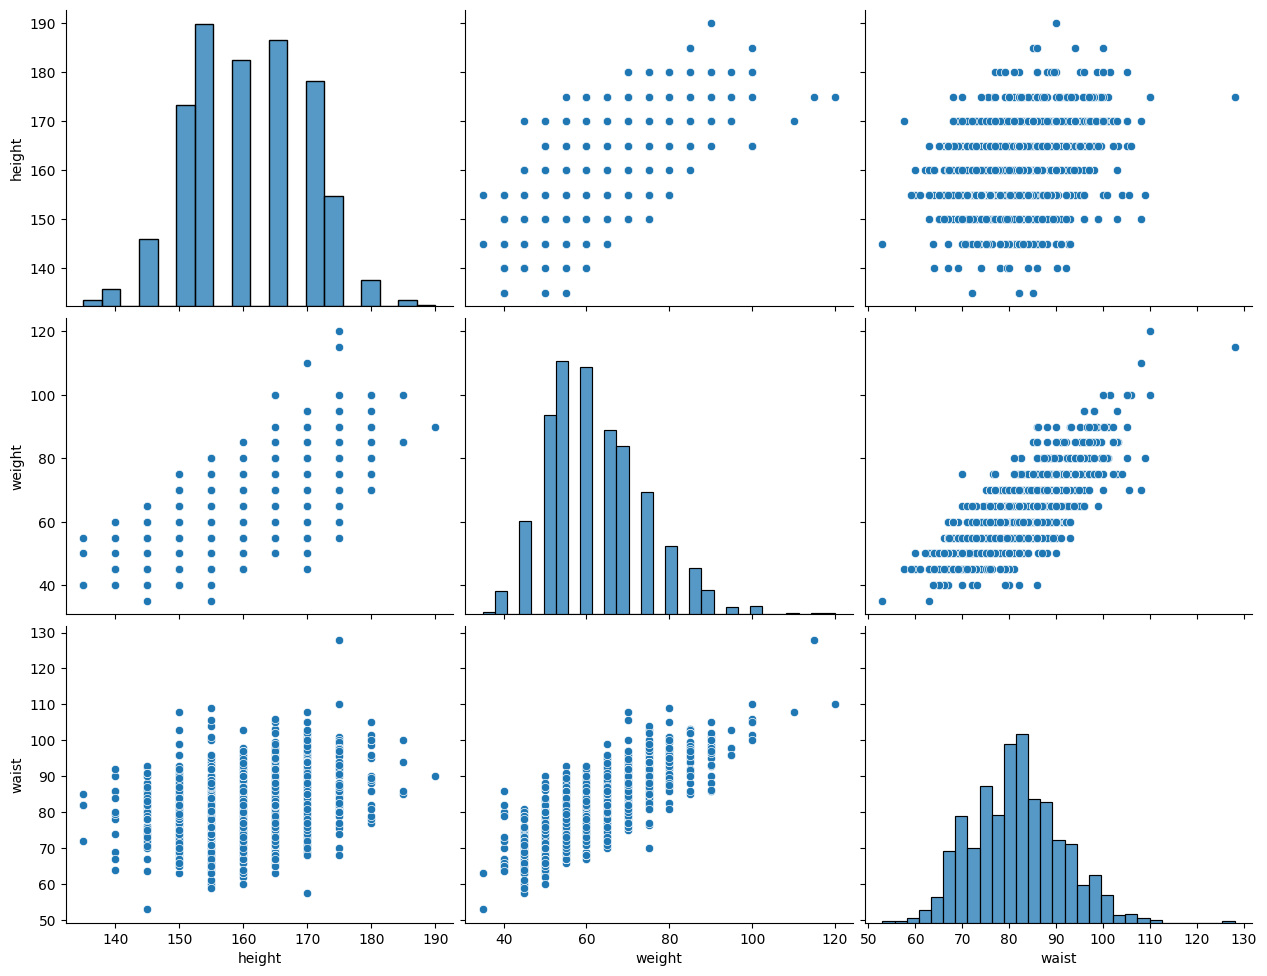

In [60]:
sns.pairplot(data6, height=3.3, aspect=1.3)
plt.show()

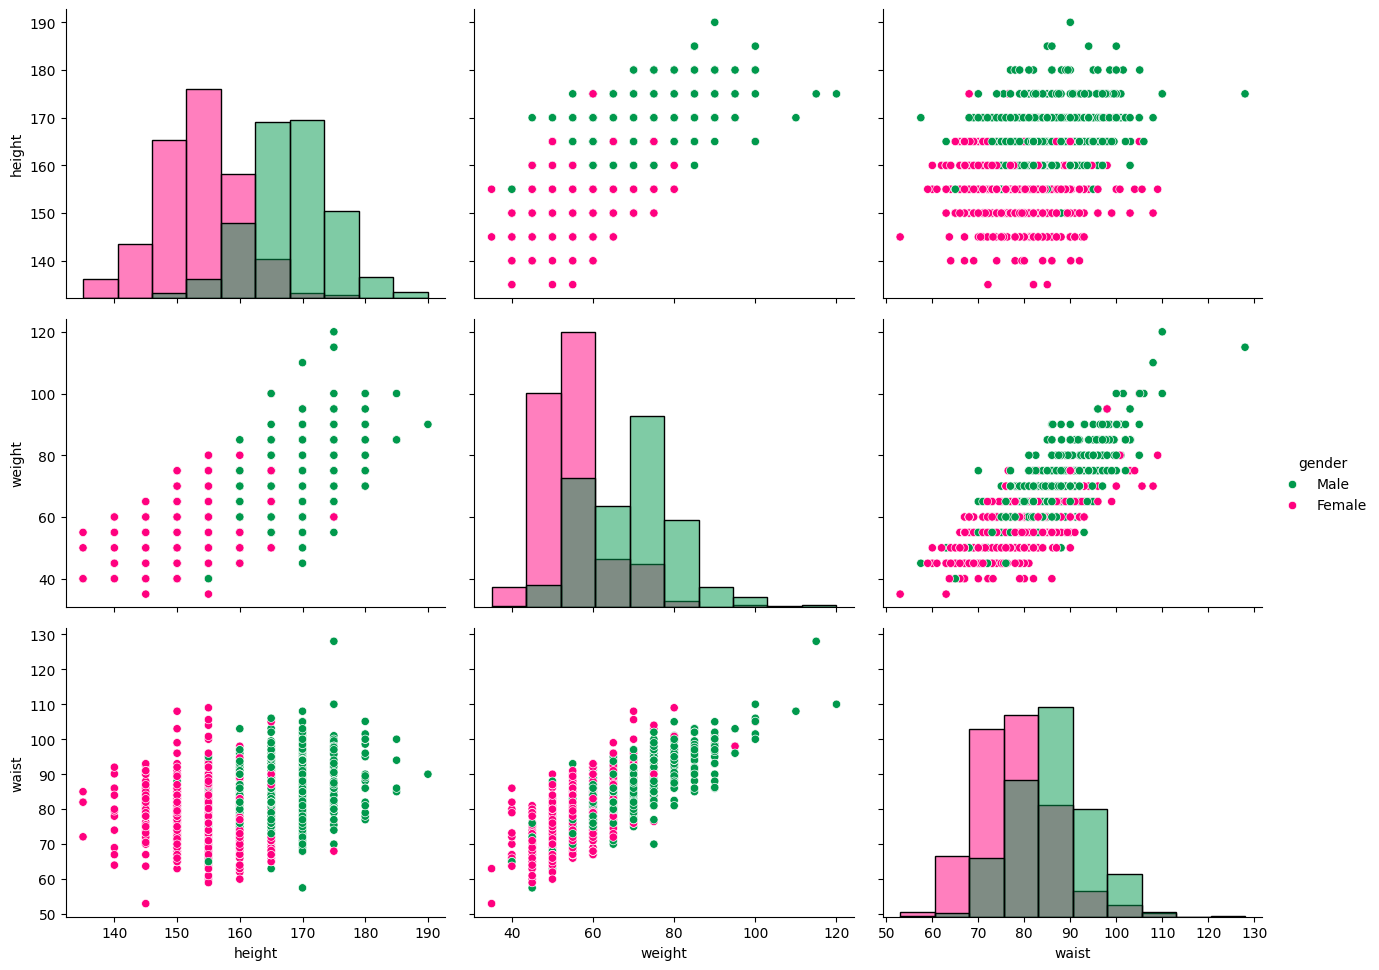

In [61]:
color = ['#00994C', '#FF007F']
pp = sns.PairGrid(data6, hue='gender', palette=color, height=3.3, aspect=1.3)
pp.map_diag(sns.histplot, bins=10)
pp.map_offdiag(sns.scatterplot)
pp.add_legend()
plt.show()

`int64` 타입 컬럼에 문자열을 넣으려고 해서 발생하는 에러예요.

**원인**

`gender` 컬럼이 원래 `1`, `2` 같은 **정수(int64)** 로 저장되어 있는데, 거기에 `'Male'` 같은 **문자열**을 넣으려니 타입이 안 맞아서 거부하는 거예요.

pandas가 예전엔 자동으로 타입을 바꿔줬는데, **버전업 되면서 엄격해졌어요.**

---

**해결 방법 3가지**

**① `.map()` 사용 (가장 깔끔)**
```python
data6['gender'] = data6['gender'].map({1: 'Male', 2: 'Female'})
data6['drinking'] = data6['drinking'].map({0: 'Non-drinking', 1: 'Drinking'})
data6['smoking'] = data6['smoking'].map({0: 'Non-smoking', 1: 'Smoking'})
```

**② 컬럼을 object 타입으로 먼저 변환**
```python
data6['gender'] = data6['gender'].astype(object)
data6.loc[data6['gender']==1, ['gender']] = 'Male'
data6.loc[data6['gender']==2, ['gender']] = 'Female'
```

**③ `replace()` 사용**
```python
data6['gender'] = data6['gender'].replace({1: 'Male', 2: 'Female'})
data6['drinking'] = data6['drinking'].replace({0: 'Non-drinking', 1: 'Drinking'})
```

---

**추천은 ①번 `.map()`** — 코드도 짧고, AICE 시험에서도 자주 쓰는 패턴이라 학생들한테 익혀두게 하면 좋아요!

## pandas `.map()` 완전 정리

---

### 기본 공식

```python
Series.map(arg, na_action=None)
```

| 파라미터 | 설명 |
|---|---|
| `arg` | 딕셔너리, 함수, 또는 Series |
| `na_action` | `None`(기본) 또는 `'ignore'` (NaN 처리 방식) |

> **핵심**: `.map()`은 **Series(컬럼) 단위**로 작동 — DataFrame 전체에는 못 씀

---

### 사용 방법 3가지

**① 딕셔너리로 값 치환** ← 가장 많이 씀
```python
df['gender'] = df['gender'].map({1: 'Male', 2: 'Female'})
```
```
기존값  →  변환값
  1    →   Male
  2    →   Female
```

**② 함수로 변환**
```python
df['height'] = df['height'].map(lambda x: x / 100)  # cm → m
```

**③ 다른 Series로 매핑**
```python
code = pd.Series({1: 'Male', 2: 'Female'})
df['gender'] = df['gender'].map(code)
```

---

### NaN 처리 주의사항

딕셔너리에 **없는 값**은 자동으로 `NaN`이 됨!

```python
df['gender'] = df['gender'].map({1: 'Male'})
# 2는 딕셔너리에 없으므로 → NaN
```

```python
# na_action='ignore' → NaN은 건드리지 않고 그대로 유지
df['gender'] = df['gender'].map({1: 'Male', 2: 'Female'}, na_action='ignore')
```

---

### `.map()` vs 비슷한 함수 비교

| 함수 | 대상 | 주요 용도 |
|---|---|---|
| `.map()` | Series | 값 1:1 치환, 간단한 변환 |
| `.apply()` | Series / DataFrame | 복잡한 함수 적용 |
| `.replace()` | Series / DataFrame | 값 치환 (타입 유연) |

```python
# 셋 다 결과는 같지만 내부 동작이 다름
df['gender'].map({1: 'Male', 2: 'Female'})
df['gender'].apply(lambda x: 'Male' if x==1 else 'Female')
df['gender'].replace({1: 'Male', 2: 'Female'})
```

---

### 실전 예시 (오늘 코드 적용)

```python
data6 = data[['gender', 'height', 'weight', 'waist', 'drinking', 'smoking']]

data6['gender']   = data6['gender'].map({1: 'Male', 2: 'Female'})
data6['drinking'] = data6['drinking'].map({0: 'Non-drinking', 1: 'Drinking'})
data6['smoking']  = data6['smoking'].map({0: 'Non-smoking',  1: 'Smoking'})
```

**변환 전후 타입 확인:**
```python
print(data6.dtypes)
# gender      object  ← int64에서 바뀜
# drinking    object
# smoking     object
```

---

### 한 줄 요약

> **`.map()`** = 컬럼의 각 값을 딕셔너리/함수 기준으로 **1:1 변환**하는 가장 깔끔한 방법

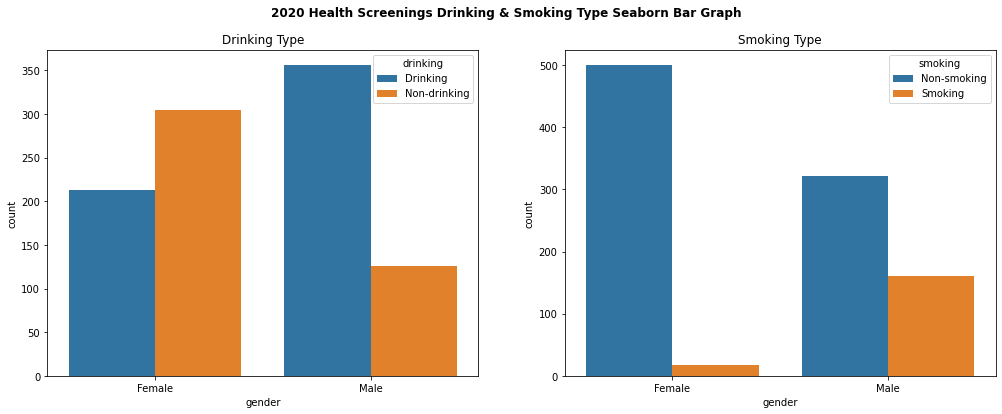

In [ ]:
fig = plt.figure(figsize=(17,6))

area1 = fig.add_subplot(1,2,1)
area2 = fig.add_subplot(1,2,2)

ax1 = sns.barplot(data=drinking,x='gender',y='count',hue='drinking',ax=area1)
ax2 = sns.barplot(data=smoking,x='gender',y='count',hue='smoking',ax=area2)

fig.suptitle('2020 Health Screenings Drinking & Smoking Type Seaborn Bar Graph',fontweight='bold')
area1.set_title('Drinking Type')
area2.set_title('Smoking Type')

plt.show()

In [ ]:
male_data = data6.loc[data6.gender=='Male',['gender','weight','waist','drinking','smoking']]
female_data = data6.loc[data6.gender=='Female',['gender','weight','waist','drinking','smoking']]

In [ ]:
min(female_data['waist'])

53.0

In [ ]:
max(male_data['waist'])

128.0

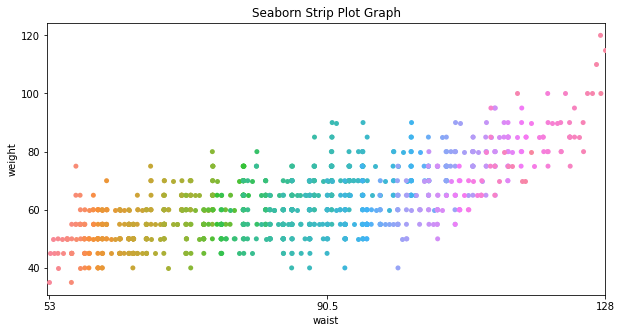

In [ ]:
plt.figure(figsize=(10,5))
plt.title('Seaborn Strip Plot Graph')

sns.stripplot(data=male_data, x='waist', y='weight')
sns.stripplot(data=female_data, x='waist', y='weight', )
#sns.stripplot(data=data6, x='waist', y='weight', hue='gender')

plt.xticks(np.arange(0,127,63), labels=[53, 90.5, 128])
plt.show()

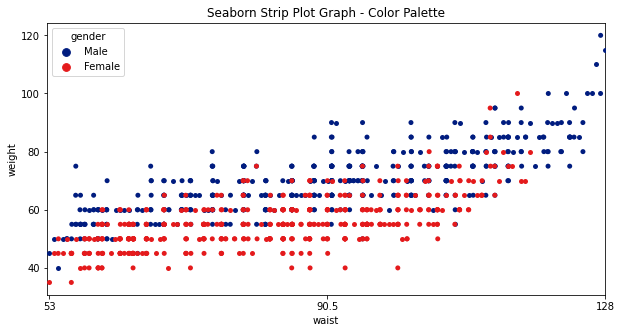

In [ ]:
plt.figure(figsize=(10,5))
plt.title('Seaborn Strip Plot Graph - Color Palette')

sns.stripplot(data=male_data, x='waist', y='weight', hue='gender', palette='dark')
sns.stripplot(data=female_data, x='waist', y='weight', hue='gender', palette='Set1')

plt.xticks(np.arange(0,127,63), labels=[53, 90.5, 128])
plt.show()

In [ ]:
male_data_100 = male_data.head(100)
female_data_100 = female_data.head(100)

/usr/local/lib/python3.8/dist-packages/seaborn/categorical.py:1296: UserWarning: 14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


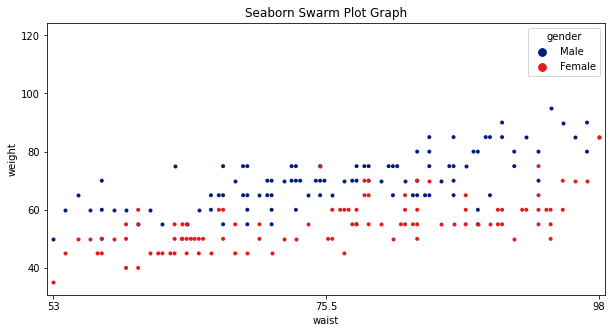

In [ ]:
plt.figure(figsize=(10,5))
plt.title('Seaborn Swarm Plot Graph')

sns.swarmplot(data=male_data_100,x='waist',y='weight',hue='gender',palette='dark',size=4)
sns.swarmplot(data=female_data_100,x='waist',y='weight',hue='gender',palette='Set1',size=4)

plt.xticks(np.arange(0,46,22.5), labels=[53, 75.5, 98])
plt.show()

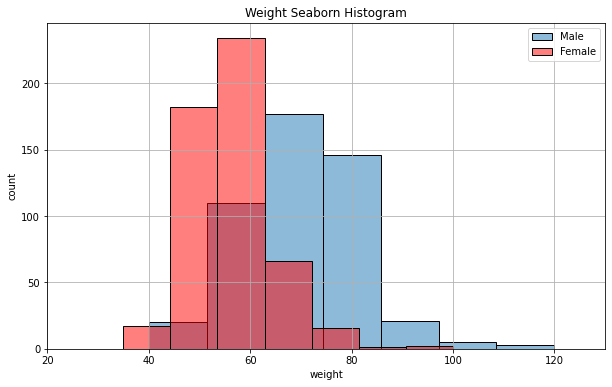

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(male_data['weight'], bins=7, alpha=0.5, label='Male')
sns.histplot(female_data['weight'], bins=7, alpha=0.5, label='Female', color='r')

plt.xlim(20,130)
plt.xlabel('weight')
plt.ylabel('count')
plt.title('Weight Seaborn Histogram')
plt.legend()
plt.grid()
plt.show()

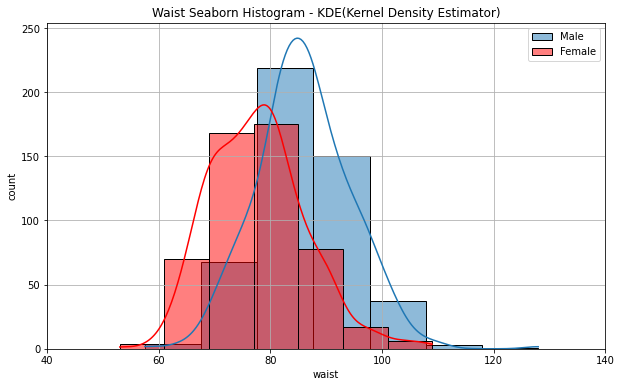

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(male_data['waist'], bins=7, alpha=0.5, label='Male', kde=True)
sns.histplot(female_data['waist'], bins=7, alpha=0.5, label='Female', color='r', kde=True)

plt.xlim(40,140)
plt.xlabel('waist')
plt.ylabel('count')
plt.title('Waist Seaborn Histogram - KDE(Kernel Density Estimator)')
plt.legend()
plt.grid()
plt.show()

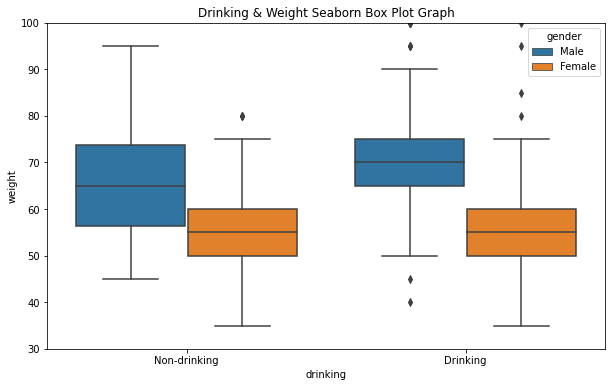

In [ ]:
plt.figure(figsize=(10,6))
plt.title('Drinking & Weight Seaborn Box Plot Graph')

sns.boxplot(data=data6, x='drinking', y='weight', hue='gender')
plt.ylim(30,100)
plt.show()

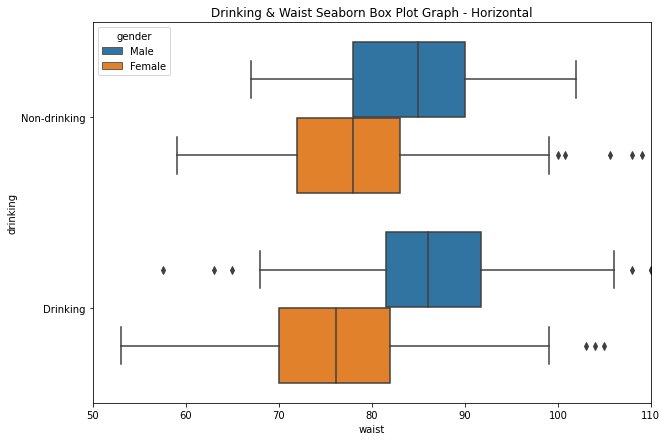

In [ ]:
plt.figure(figsize=(10,7))
plt.title('Drinking & Waist Seaborn Box Plot Graph - Horizontal')

sns.boxplot(data=data6, x='waist', y='drinking', hue='gender', orient='h')
plt.xlim(50,110)
plt.show()

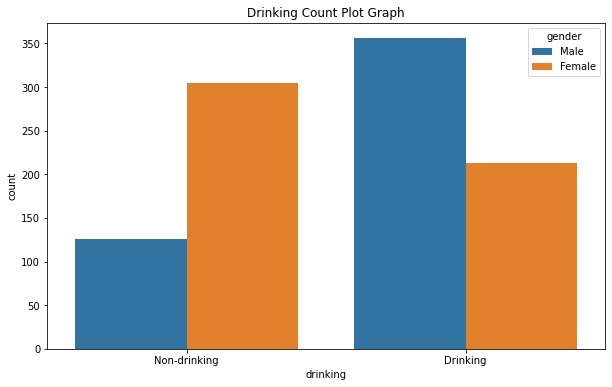

In [ ]:
plt.figure(figsize=(10,6))
plt.title('Drinking Count Plot Graph')
sns.countplot(data=data6, x='drinking', hue='gender')
plt.show()

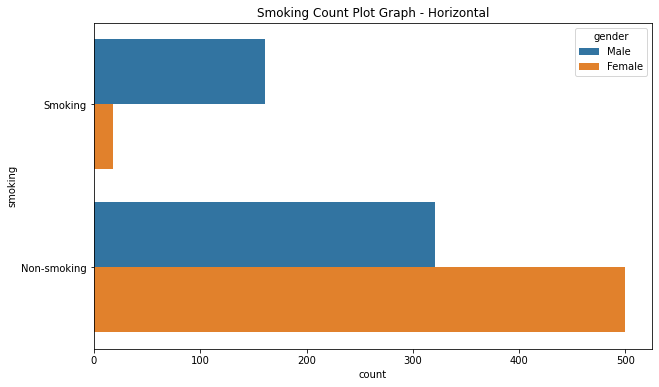

In [ ]:
plt.figure(figsize=(10,6))
plt.title('Smoking Count Plot Graph - Horizontal')
sns.countplot(data=data6, y='smoking', hue='gender', order=['Smoking','Non-smoking'])
plt.show()

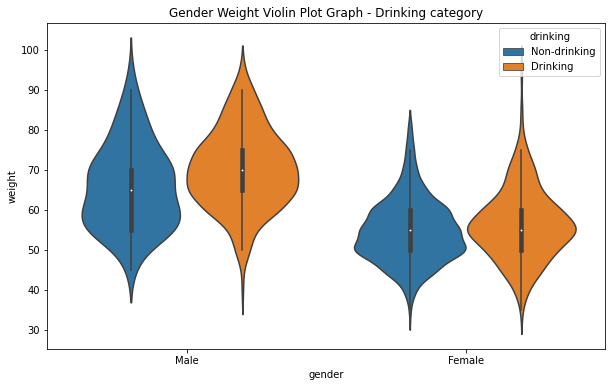

In [ ]:
plt.figure(figsize=(10,6))
plt.title('Gender Weight Violin Plot Graph - Drinking category')
sns.violinplot(data=data6[data6.weight<100], x='gender', y='weight', hue='drinking')
plt.show()

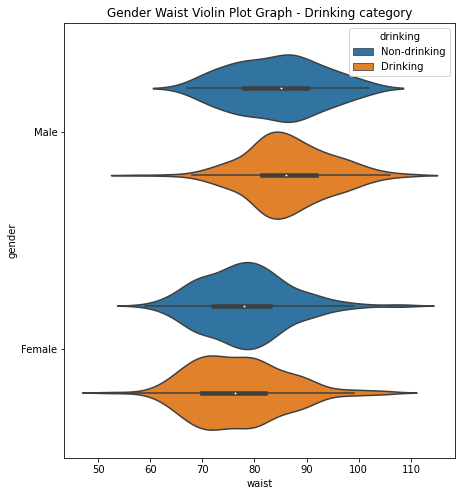

In [ ]:
plt.figure(figsize=(7,8))
plt.title('Gender Waist Violin Plot Graph - Drinking category')
sns.violinplot(data=data6[data6.waist<120], y='gender', x='waist', hue='drinking')
plt.show()

In [ ]:
data3 = data.loc[:,['gender','weight','waist']]
data8 = data.loc[:,['gender','weight','waist','drinking','smoking','cholesterol','HDL','LDL']]

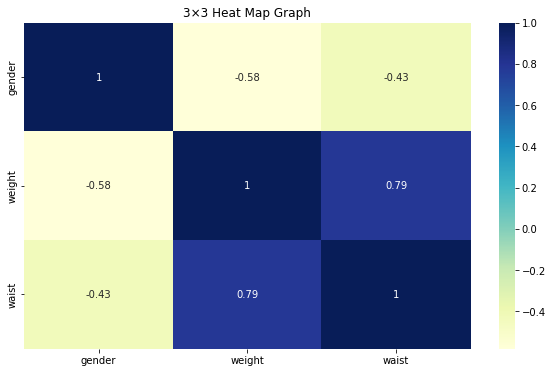

In [ ]:
plt.figure(figsize=(10,6))
plt.title('3×3 Heat Map Graph')

correlation_data3 = data3.corr()
sns.heatmap(correlation_data3, annot=True, cmap='YlGnBu')
plt.show()

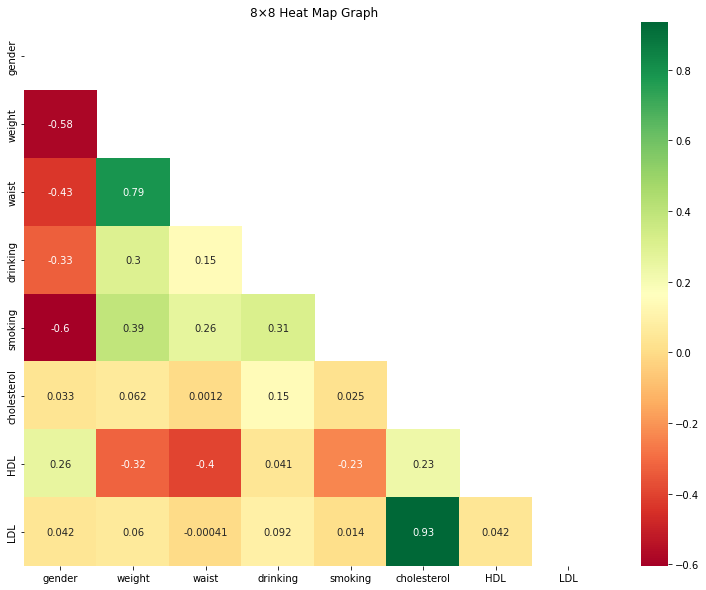

In [ ]:
plt.figure(figsize=(13,10))
plt.title('8×8 Heat Map Graph')

correlation_data8= data8.corr()
upp_mat = np.triu(correlation_data8)

sns.heatmap(correlation_data8, annot=True, cmap='RdYlGn', mask=upp_mat)
plt.show()

In [ ]:
data12 = data.loc[:,['gender','weight','waist','drinking','smoking','AST','ALT','systolic','diastolic','cholesterol','HDL','LDL']]

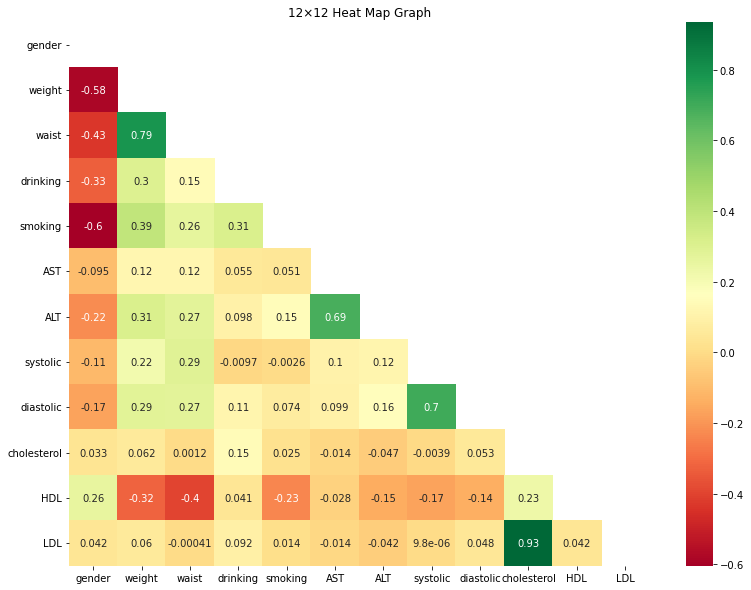

In [ ]:
plt.figure(figsize=(13,10))
plt.title('12×12 Heat Map Graph')

correlation_data12= data12.corr()
upp_mat = np.triu(correlation_data12)

sns.heatmap(correlation_data12, annot=True, cmap='RdYlGn', mask=upp_mat)
plt.show()

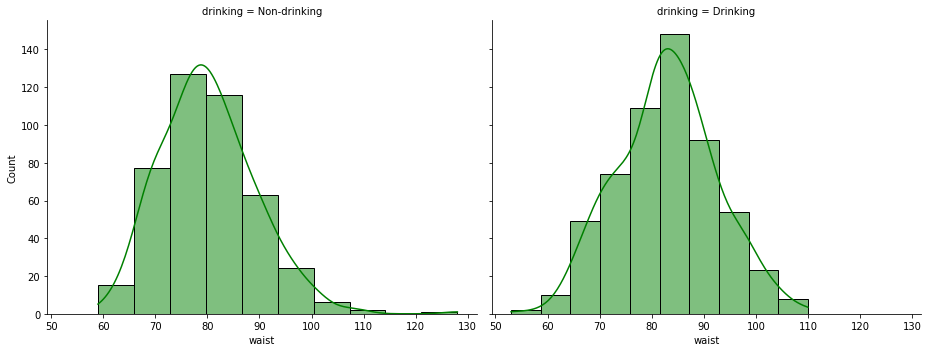

In [ ]:
fg = sns.FacetGrid(data6, col='drinking', height=5, aspect=1.3)
fg.map(sns.histplot, 'waist', bins=10, color='g', kde=True)
plt.show()

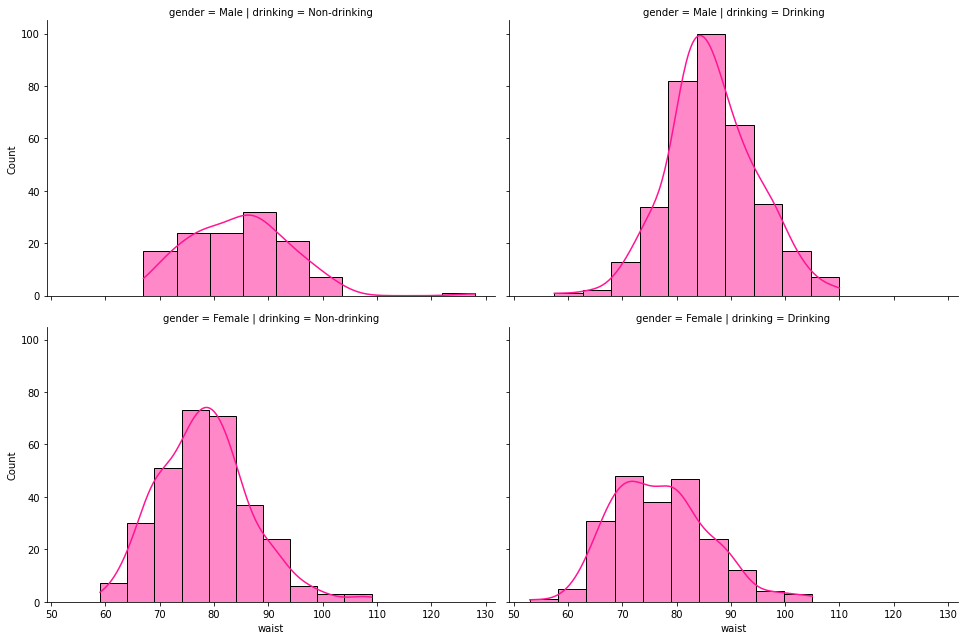

In [ ]:
fg = sns.FacetGrid(data6, row='gender', col='drinking', height=4.5, aspect=1.5)
fg.map(sns.histplot, 'waist', bins=10, color='deeppink', kde=True)
plt.show()

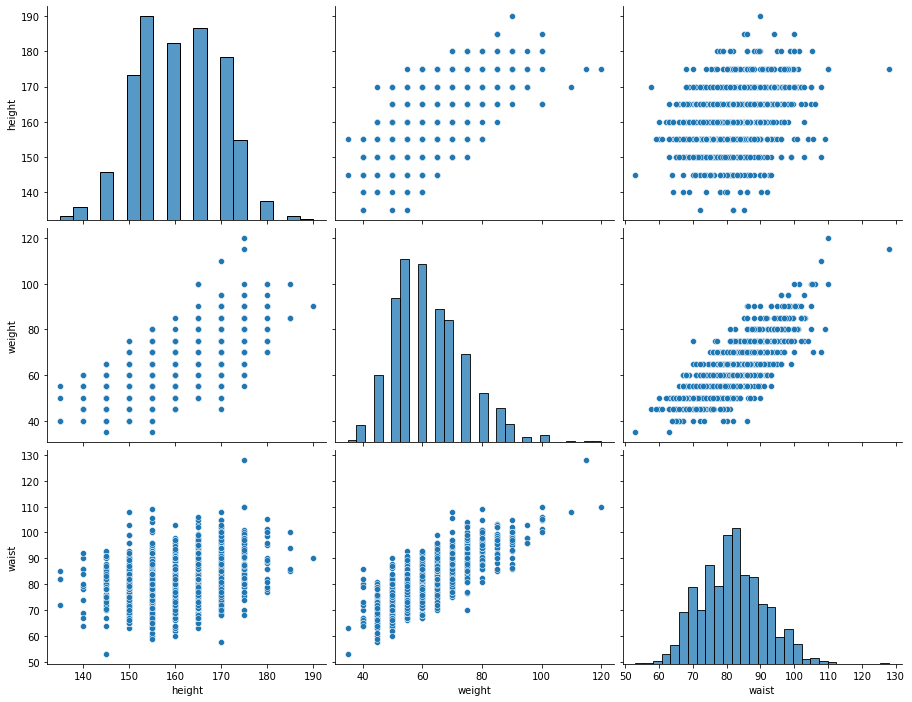

In [ ]:
sns.pairplot(data6, height=3.3, aspect=1.3)
plt.show()

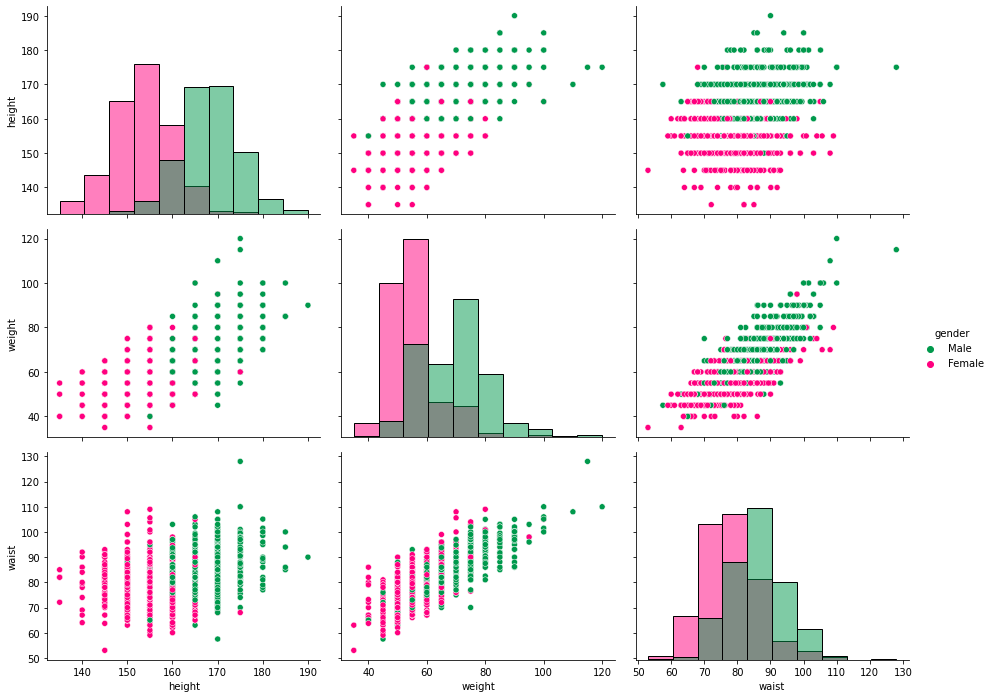

In [ ]:
color = ['#00994C', '#FF007F']
pp = sns.PairGrid(data6, hue='gender', palette=color, height=3.3, aspect=1.3)
pp.map_diag(sns.histplot, bins=10)
pp.map_offdiag(sns.scatterplot)
pp.add_legend()
plt.show()